# Foresight: Model Selection & Comparison
This notebook allows you to independently train and evaluate different candidate models. By running each model in its own cell, you can easily inspect individual performance, tweak hyperparameters, and generate custom graphs for side-by-side comparison.


## 1. Setup & Data Loading


In [1]:
import os
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, auc, precision_recall_curve, roc_curve, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style="whitegrid", palette="muted")

# Global results dictionary to store metrics for comparison
model_results = {}

def plot_evaluation(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Store metrics
    pr_vals, rc_vals, _ = precision_recall_curve(y_test, y_prob)
    model_results[model_name] = {
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
        'PR-AUC': auc(rc_vals, pr_vals),
        'y_prob': y_prob
    }
    
    print(f"--- {model_name} Evaluation ---")
    print(classification_report(y_test, y_pred))
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred, normalize='true')
    sns.heatmap(cm, annot=True, fmt=".2%", cmap="Blues", ax=axes[0])
    axes[0].set_title(f"Normalized Confusion Matrix ({model_name})")
    axes[0].set_ylabel("Actual")
    axes[0].set_xlabel("Predicted")
    
    # PR Curve
    axes[1].plot(rc_vals, pr_vals, color='darkorange', lw=2)
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].set_title(f"Precision-Recall Curve (AUC = {model_results[model_name]['PR-AUC']:.3f})")
    
    plt.tight_layout()
    plt.show()

# Load and prepare data
df = pd.read_csv('../data/raw/ai4i2020.csv')
df.columns = [c.strip() for c in df.columns]
df = df.drop(columns=["UDI", "Product ID", "TWF", "HDF", "PWF", "OSF", "RNF"])
df = pd.get_dummies(df, columns=["Type"], drop_first=True)

df["Temp_Diff"] = df["Process temperature [K]"] - df["Air temperature [K]"]
df["Power"] = df["Torque [Nm]"] * (df["Rotational speed [rpm]"] * 2 * np.pi / 60)
df["Tool_Wear_Rate"] = df["Tool wear [min]"] * df["Torque [Nm]"]

X = df.drop(columns=["Machine failure"])
y = df["Machine failure"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print(f"Training shape after SMOTE: {X_train_res.shape}")
print(f"Testing shape: {X_test_scaled.shape}")


Training shape after SMOTE: (15458, 10)
Testing shape: (2000, 10)


## 2. Baseline Model: Logistic Regression


Training Logistic Regression...
--- Logistic Regression Evaluation ---
              precision    recall  f1-score   support

           0       1.00      0.86      0.92      1932
           1       0.19      0.88      0.31        68

    accuracy                           0.86      2000
   macro avg       0.59      0.87      0.62      2000
weighted avg       0.97      0.86      0.90      2000



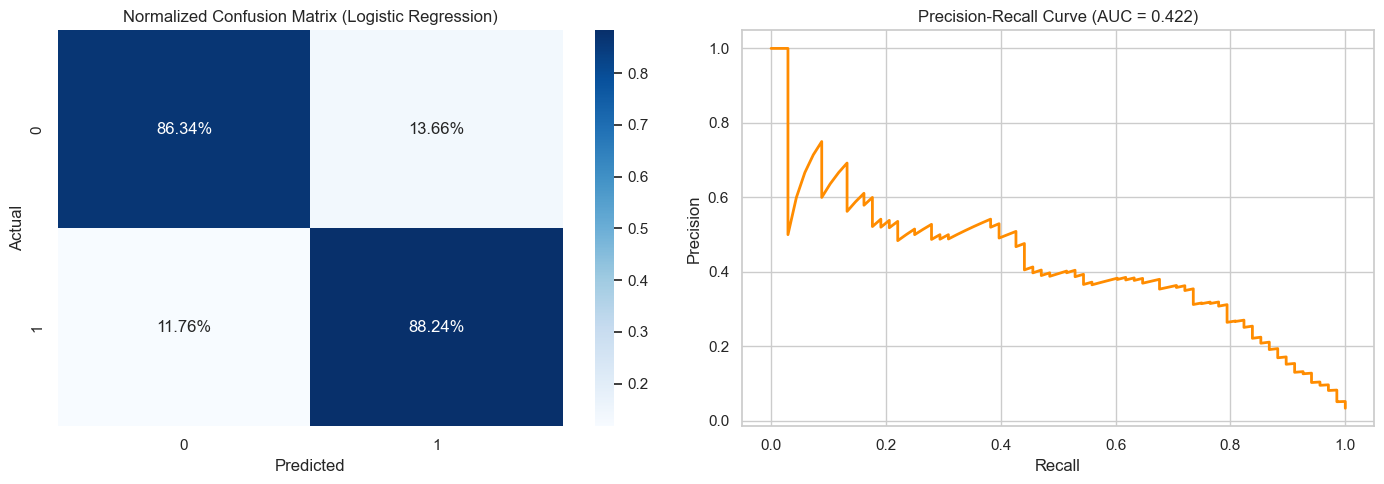

In [2]:
print("Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_res, y_train_res)

plot_evaluation(lr, X_test_scaled, y_test, "Logistic Regression")


## 3. Ensemble Model: Random Forest


Training Random Forest...
--- Random Forest Evaluation ---
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      1932
           1       0.55      0.82      0.66        68

    accuracy                           0.97      2000
   macro avg       0.77      0.90      0.82      2000
weighted avg       0.98      0.97      0.97      2000



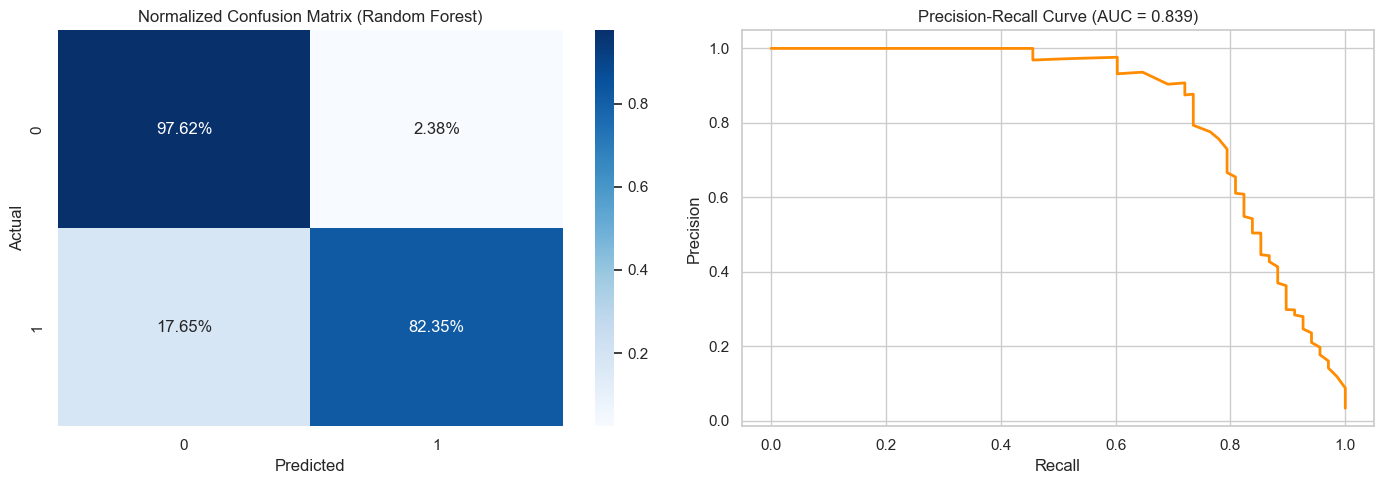

In [3]:
print("Training Random Forest...")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_res, y_train_res)

plot_evaluation(rf, X_test_scaled, y_test, "Random Forest")


## 4. Sequential Ensemble: Gradient Boosting


Training Gradient Boosting...
--- Gradient Boosting Evaluation ---
              precision    recall  f1-score   support

           0       1.00      0.95      0.97      1932
           1       0.39      0.88      0.54        68

    accuracy                           0.95      2000
   macro avg       0.69      0.92      0.76      2000
weighted avg       0.98      0.95      0.96      2000



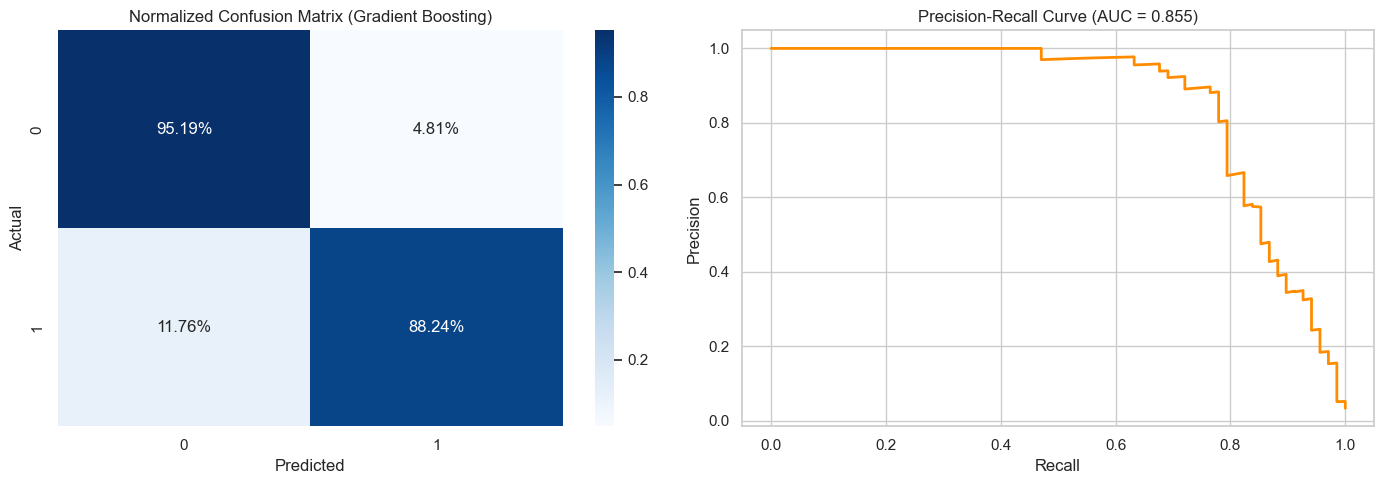

In [4]:
print("Training Gradient Boosting...")
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train_res, y_train_res)

plot_evaluation(gb, X_test_scaled, y_test, "Gradient Boosting")


## 5. Deep Learning: MLP Neural Network


Training MLP Classifier...
--- MLP Neural Network Evaluation ---
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1932
           1       0.48      0.79      0.60        68

    accuracy                           0.96      2000
   macro avg       0.74      0.88      0.79      2000
weighted avg       0.98      0.96      0.97      2000



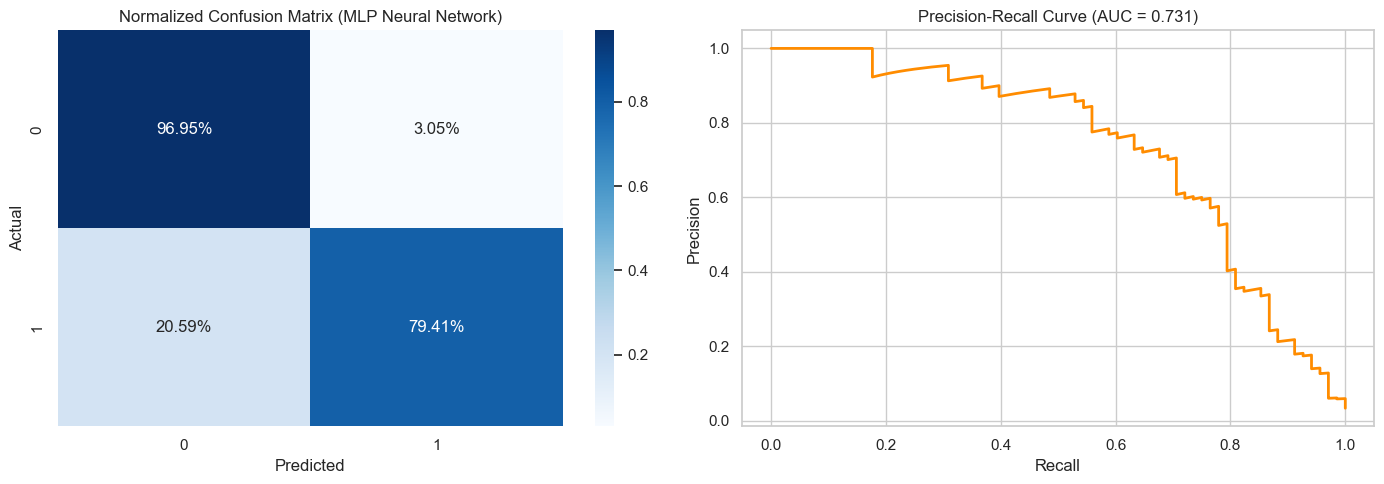

In [5]:
print("Training MLP Classifier...")
mlp = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)
mlp.fit(X_train_res, y_train_res)

plot_evaluation(mlp, X_test_scaled, y_test, "MLP Neural Network")


## 6. Model Comparison


Final Evaluation Metrics:


,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
Logistic Regression,0.185185,0.882353,0.306122,0.939509,0.421944
Random Forest,0.54902,0.823529,0.658824,0.979757,0.838832
Gradient Boosting,0.392157,0.882353,0.542986,0.978013,0.855485
MLP Neural Network,0.477876,0.794118,0.596685,0.961287,0.731486


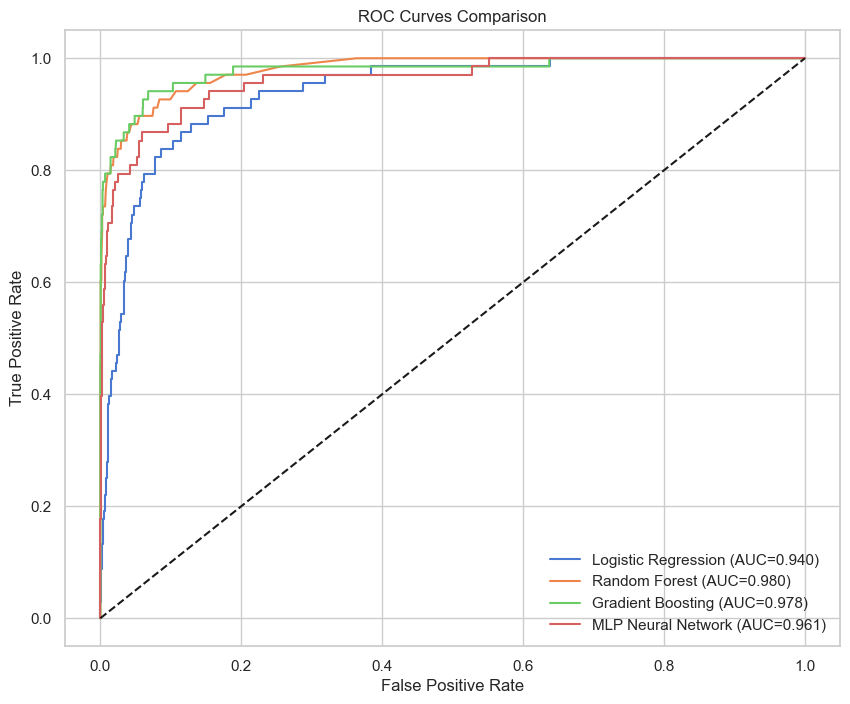

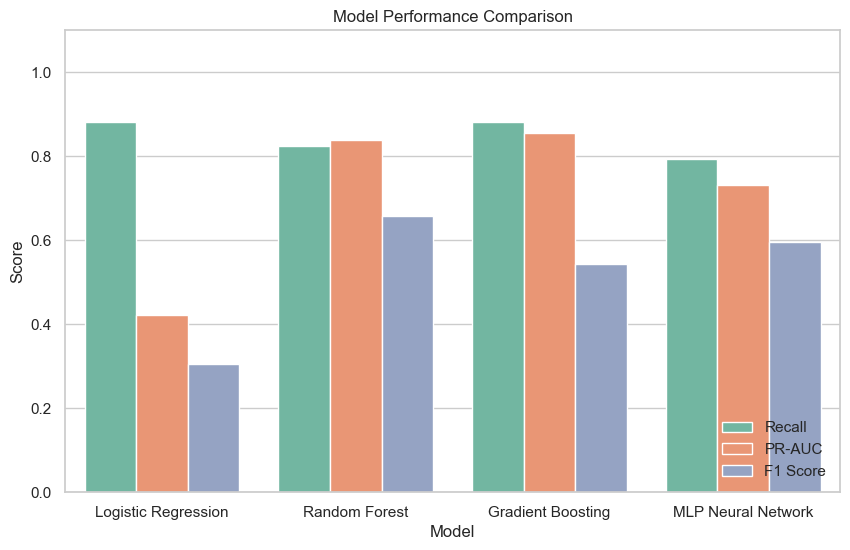

In [6]:
results_df = pd.DataFrame(model_results).T.drop(columns=['y_prob'])
print("Final Evaluation Metrics:")
display(results_df)

# Plot ROC Curves overlaid
plt.figure(figsize=(10, 8))
for name in model_results.keys():
    fpr, tpr, _ = roc_curve(y_test, model_results[name]['y_prob'])
    roc_auc = model_results[name]['ROC-AUC']
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curves Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

# Plot Metric Comparison Bar Chart
res_melted = results_df.reset_index().melt(id_vars="index", value_vars=["Recall", "PR-AUC", "F1 Score"], var_name="Metric", value_name="Score")
res_melted.rename(columns={"index": "Model"}, inplace=True)

plt.figure(figsize=(10, 6))
sns.barplot(data=res_melted, x="Model", y="Score", hue="Metric", palette="Set2")
plt.title("Model Performance Comparison")
plt.ylim(0, 1.1)
plt.legend(loc='lower right')
plt.show()


## 6. Combined Precision-Recall Curve
Here we plot the Precision-Recall curves for all evaluated models on a single graph to directly compare their ability to capture failures (Recall) against their false alarm rate (Precision).

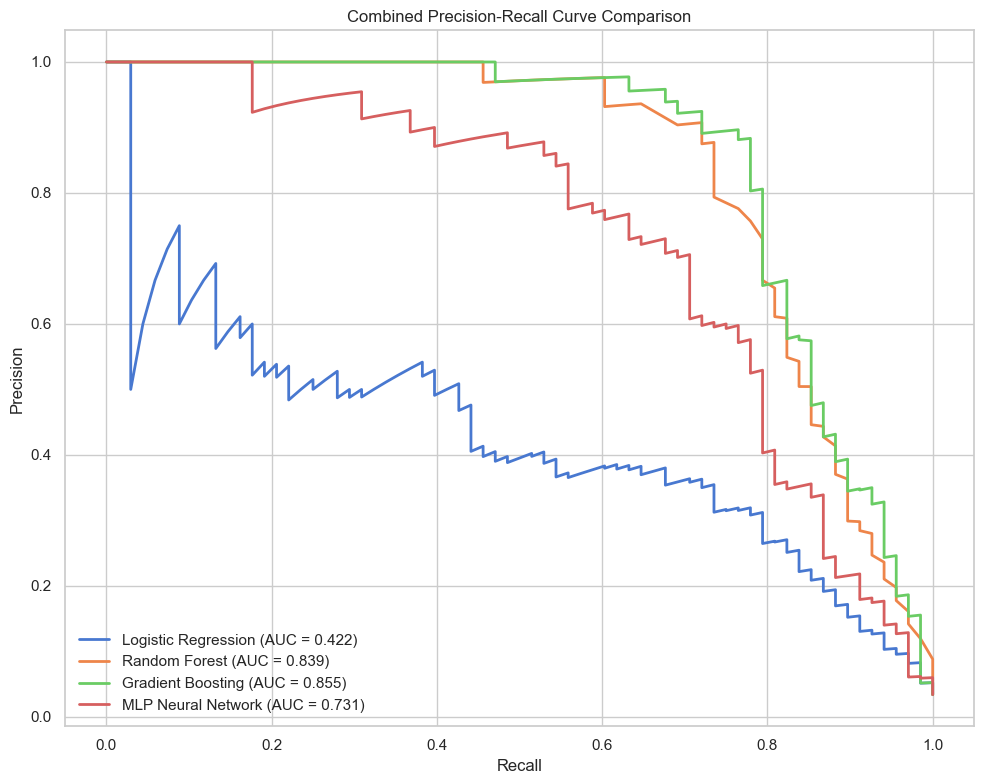

In [7]:
plt.figure(figsize=(10, 8))

for name, results in model_results.items():
    y_prob = results['y_prob']
    pr_vals, rc_vals, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(rc_vals, pr_vals)
    plt.plot(rc_vals, pr_vals, lw=2, label=f'{name} (AUC = {pr_auc:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Combined Precision-Recall Curve Comparison')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()
